<a href="https://colab.research.google.com/github/azka1404/Tugas-Project_Kelompok-14/blob/main/Tugas_Project_Kelompok_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Penerapan Algoritma K-Means Clustering untuk Pemetaan Kompetensi dan Kesejahteraan Guru SMP/MTs
## Berdasarkan Data Asesmen Nasional 2025

**Kelompok 14 R4 Muhammad Azka Hammam, Tafif Maulana Rahman, Fariz Afandi — Pendidikan Matematika, Universitas Negeri Semarang**

Tahapan **KDD (Knowledge Discovery in Database)**:
1. Data Selection
2. Pre-Processing (cek missing value, duplikasi)
3. Transformation (Min-Max Scaling)
4. Data Mining (K-Means Clustering)
5. Evaluasi & Interpretasi (Elbow, Davies-Bouldin Index, Silhouette Score)

**Variabel yang digunakan:**
- `ACH` — Ekspektasi Akademik menurut Guru
- `AIN` — Instruksi Adaptif menurut Guru
- `CAF` — Umpan Balik Konstruktif menurut Guru
- `COP` — Refleksi atas Praktik Mengajar Guru
- `SCO` — Perasaan Terhubung dengan Sekolah

## 0. Instalasi & Import Library

In [87]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn openpyxl

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', None)
print('Library siap digunakan.')

Library siap digunakan.


## 1. Data Selection



In [89]:
FILE_PATH = '/content/rapor-publik-asesmen-nasional-2025-guru-2025-smp-mts-sederajat (1).xlsx'

In [90]:
xl = pd.ExcelFile(FILE_PATH, engine='openpyxl')
print('Sheet tersedia:', xl.sheet_names)

df_raw = pd.read_excel(xl, sheet_name='rapor_publik')
print('Jumlah baris:', df_raw.shape[0])
print('Jumlah kolom:', df_raw.shape[1])
df_raw.head()

Sheet tersedia: ['codebook_guru', 'rapor_publik']
Jumlah baris: 256078
Jumlah kolom: 92


,kd_guru_an,kd_sekolah,pendidikan_sederajat,jenis_sek,sts_sek,kurikulum,daerah_khusus,kd_kokab,wilayah_bagian,jenis_wilayah,status_wilayah,proporsi_pendidik_min_s1,proporsi_pendidik_sertifikasi,jumlah_peserta_didik,jumlah_pendidik,rasio_pendidik_peserta_didik,jumlah_r_kelas,ketersediaan_internet,ketersediaan_listrik,jumlah_komp_milik,jumlah_perpus,jumlah_rombel,jumlah_siswa_rombel,jumlah_siswa_penerima_PIP,rasio_siswa_penerima_PIP,SES_sekolah,ACH,AIN,AKC,APC,APK,BBS,BCP,CAF,COP,CSV,ENP,EQC,EQR,HWS,ITB,JOT,KKG,KPC,KPK,KSA,LCS,LFO,MIP,NAT,OCC,OPC,PBR,PBU,PCP,PGP,PIP,PKG,PMU,POT,PPC,PPK,PSA,PSV,RC,RPI,SBU,SCO,SKG,SSV,TAS,TOC,TOR,TSC,SMK_GRMAG,SMK_GTINS,SMK_INDS,SMK_KLAB,SMK_KOMITE,SMK_KPL,SMK_PBEL,SMK_PIM,SMK_PKL,SMK_PKUR,SMK_SARPRAS,SMK_TEFA,SPAB_1,SPAB_2,SPAB_3,SPAB_4,SPAB_5,SPAB_6
0,25-4100781-20246745,4100781,SMP/MTs,MTs,N,NaN,Tidak,45,Indonesia Barat,KABUPATEN,URBAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.95,71.4058,70.0155,55.7394,NaN,64.0832,73.8446,46.0372,NaN,62.1459,85.1927,63.4629,42.2373,57.7365,19.5898,49.1866,41.6590,NaN,74.5605,86.2376,61.6019,NaN,NaN,28.0036,NaN,42.5415,52.6265,63.6553,22.8813,47.2446,44.7844,52.7527,76.1903,NaN,18.0083,53.5246,NaN,52.4820,23.7877,42.3111,28.4796,NaN,NaN,50.8974,NaN,52.3202,72.5748,65.4813,38.8109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.0957,19.3576,NaN,55.5343,32.8904,31.4923
1,25-4100781-20657548,4100781,SMP/MTs,MTs,N,NaN,Tidak,45,Indonesia Barat,KABUPATEN,URBAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.95,74.9801,61.7466,74.6640,36.9082,68.1475,NaN,56.5191,77.1057,NaN,NaN,87.7552,68.0810,NaN,NaN,53.1100,NaN,49.4555,41.5718,NaN,66.4739,44.1322,60.5704,NaN,82.3687,57.6165,54.0856,72.8972,69.1527,80.7880,66.8289,64.9959,NaN,71.5548,54.8548,NaN,49.0446,61.0210,66.3311,63.6838,98.5014,53.3163,96.5459,54.2307,88.0900,52.9572,68.2539,80.6487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.2873,70.3993,NaN,93.7022,63.7874,100.0000
2,25-4100781-20657550,4100781,SMP/MTs,MTs,N,NaN,Tidak,45,Indonesia Barat,KABUPATEN,URBAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.95,74.9007,NaN,97.9319,59.6135,NaN,100.0000,52.9688,80.2014,88.5837,30.4048,NaN,NaN,84.4384,76.7702,85.9330,71.8663,50.4537,NaN,72.7723,92.2378,58.6777,69.6166,86.9015,71.5792,NaN,NaN,86.7082,83.3900,89.6152,85.8136,94.3302,93.2329,82.5088,60.5809,70.6557,66.4014,81.5144,68.0694,NaN,75.4463,77.9762,81.2132,NaN,67.3034,NaN,76.1022,NaN,87.8613,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.8888,59.1146,67.8911,54.8664,63.1229,NaN
3,25-4100781-20667108,4100781,SMP/MTs,MTs,N,NaN,Tidak,45,Indonesia Barat,KABUPATEN,URBAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.95,58.5385,57.1098,46.8459,NaN,50.4726,42.0519,30.7371,NaN,62.1459,28.8253,63.4629,60.0772,48.7179,47.7829,56.4593,48.8727,NaN,57.2906,68.3168,98.6787,NaN,NaN,43.5411,NaN,39.5423,39.5915,52.0250,61.3560,58.5939,52.5035,55.2999,49.7911,NaN,53.2780,53.5246,NaN,66.5238,74.7482,44.8306,62.1700,NaN,NaN,44.2948,NaN,46.4968,65.3438,60.5650,54.4178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.0957,42.1007,NaN,44.0839,37.5415,31.4923
4,25-3102329-20676756,3102329,SMP/MTs,SMP,N,Kurikulum SMP Merdeka,Tidak,45,Indonesia Barat,KABUPATEN,URBAN,1.0,0.86,39.0,7.0,0.179487,9.0,Ada,Ada,2.0,1.0,3.0,13.0,22.0,0.564103,50.98,74.9801,85.3170,64.0124,44.6377,56.8999,NaN,65.4793,47.7321,NaN,NaN,87.7552,82.2565,NaN,NaN,68.0382,NaN,49.4555,52.1199,NaN,99.1742,47.4380,58.2105,NaN,75.6318,32.5178,46.5954,86.7082,83.4747,35.7693,57.9277,64.9959,NaN,98.3215,45.7261,NaN,NaN,78.3834,57.7309,46.0469,51.3919,53.3163,71.2721,47.2436,56.2359,61.5104,76.0140,62.2386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.7586,75.8680,NaN,93.7022,27.6855,100.0000


In [91]:
N_SAMPLE = 5000

if len(df_raw) > N_SAMPLE:
    df = df_raw.sample(n=N_SAMPLE, random_state=42).reset_index(drop=True)
else:
    df = df_raw.copy()

print('Jumlah data yang digunakan:', len(df))

Jumlah data yang digunakan: 5000


In [92]:
# Variabel input clustering
FEATURES = ['ACH', 'AIN', 'CAF', 'COP', 'SCO']

df_features = df[FEATURES].copy()
df_features.describe().round(2)

,ACH,AIN,CAF,COP,SCO
count,4990.00,3332.00,3305.00,3336.00,3303.00
mean,64.13,63.23,66.28,70.61,76.93
std,15.20,13.07,17.55,10.68,14.89
min,5.88,23.88,3.10,34.42,0.67
25%,51.07,53.17,52.41,62.75,64.03
50%,64.02,61.28,62.99,69.10,75.91
75%,74.98,70.02,77.11,75.02,88.71
max,86.18,100.00,100.00,100.00,100.00


## 2. Pre-Processing Data

- Cek missing value
- Imputasi median (karena missing tersebar merata)
- Cek dan hapus duplikasi berdasarkan `kd_guru_an`
- Verifikasi rentang nilai 0–100

In [93]:
# Cek missing value sebelum imputasi
print('Jumlah missing value per variabel (sebelum imputasi):')
print(df_features.isna().sum())
print('\nPersentase missing:')
print((df_features.isna().mean() * 100).round(2))

Jumlah missing value per variabel (sebelum imputasi):
ACH      10
AIN    1668
CAF    1695
COP    1664
SCO    1697
dtype: int64

Persentase missing:
ACH     0.20
AIN    33.36
CAF    33.90
COP    33.28
SCO    33.94
dtype: float64


In [94]:
# Imputasi missing value menggunakan median per variabel
for col in FEATURES:
    median_val = df_features[col].median()
    df_features[col] = df_features[col].fillna(median_val)

print('Missing value setelah imputasi:')
print(df_features.isna().sum())

Missing value setelah imputasi:
ACH    0
AIN    0
CAF    0
COP    0
SCO    0
dtype: int64


In [95]:
# Cek duplikasi berdasarkan kode guru
if 'kd_guru_an' in df.columns:
    n_dup = df['kd_guru_an'].duplicated().sum()
    print(f'Jumlah duplikasi kode guru: {n_dup}')
    if n_dup > 0:
        keep_idx = ~df['kd_guru_an'].duplicated()
        df = df[keep_idx].reset_index(drop=True)
        df_features = df_features[keep_idx].reset_index(drop=True)
        print('Duplikasi dihapus. Sisa data:', len(df))
else:
    print('Kolom kd_guru_an tidak ditemukan, lanjut tanpa pengecekan duplikasi.')

Jumlah duplikasi kode guru: 0


In [96]:
# Verifikasi rentang nilai (harus 0-100)
for col in FEATURES:
    out_of_range = ((df_features[col] < 0) | (df_features[col] > 100)).sum()
    print(f'{col}: min={df_features[col].min():.2f}, max={df_features[col].max():.2f}, di luar 0-100: {out_of_range}')

ACH: min=5.88, max=86.18, di luar 0-100: 0
AIN: min=23.88, max=100.00, di luar 0-100: 0
CAF: min=3.10, max=100.00, di luar 0-100: 0
COP: min=34.42, max=100.00, di luar 0-100: 0
SCO: min=0.67, max=100.00, di luar 0-100: 0


In [97]:
# Statistik deskriptif final
desc = df_features.describe().T[['min', 'max', 'mean', 'std']]
desc.columns = ['Min', 'Max', 'Mean', 'SD']
desc.round(2)

,Min,Max,Mean,SD
ACH,5.88,86.18,64.13,15.19
AIN,23.88,100.00,62.58,10.71
CAF,3.10,100.00,65.17,14.36
COP,34.42,100.00,70.11,8.75
SCO,0.67,100.00,76.58,12.11


## 3. Visualisasi Distribusi Data

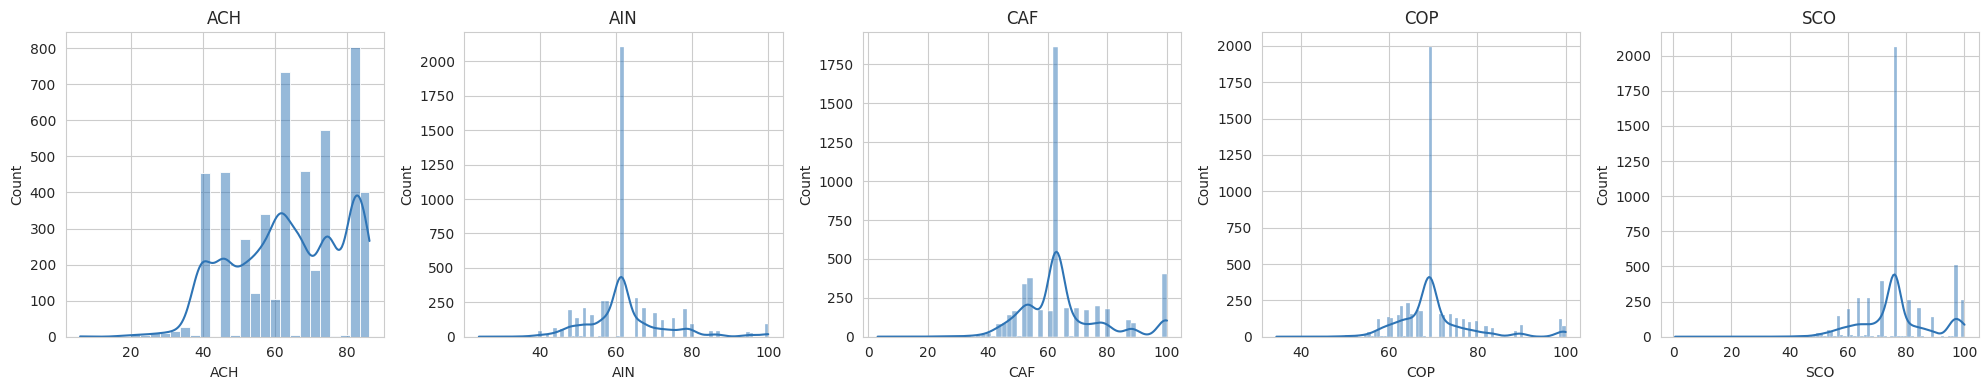

In [98]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(FEATURES):
    sns.histplot(df_features[col], kde=True, ax=axes[i], color='#2E74B5')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

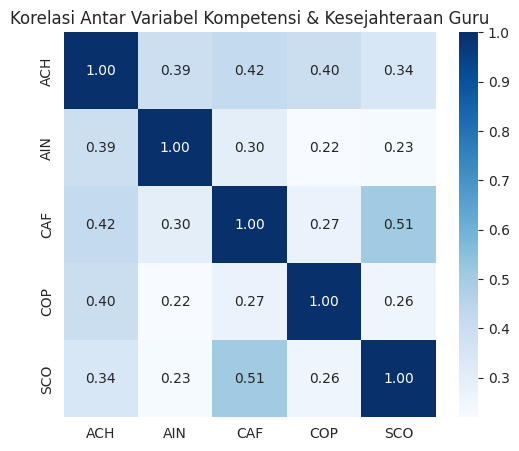

In [99]:
# Matriks korelasi antar variabel
plt.figure(figsize=(6,5))
sns.heatmap(df_features.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Korelasi Antar Variabel Kompetensi & Kesejahteraan Guru')
plt.show()

## 4. Transformation — Normalisasi (Min-Max Scaling)

Mengubah semua variabel ke rentang [0, 1] agar setiap variabel berkontribusi setara dalam perhitungan jarak Euclidean.

$$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

In [100]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_features)

df_scaled = pd.DataFrame(X_scaled, columns=FEATURES)
df_scaled.describe().round(3)

,ACH,AIN,CAF,COP,SCO
count,5000.000,5000.000,5000.000,5000.000,5000.000
mean,0.725,0.508,0.641,0.544,0.764
std,0.189,0.141,0.148,0.133,0.122
min,0.000,0.000,0.000,0.000,0.000
25%,0.563,0.437,0.529,0.467,0.711
50%,0.724,0.491,0.618,0.529,0.757
75%,0.861,0.547,0.682,0.564,0.811
max,1.000,1.000,1.000,1.000,1.000


## 5. Data Mining — Penentuan Jumlah Cluster Optimal (k)

Menjalankan K-Means untuk k = 2 hingga 6, dievaluasi menggunakan:
- **Elbow Method (WCSS / Inertia)**
- **Davies-Bouldin Index (DBI)** — semakin kecil semakin baik
- **Silhouette Score** — semakin mendekati 1 semakin baik

In [101]:
k_range = range(2, 7)
results = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42, max_iter=200)
    labels = km.fit_predict(X_scaled)

    wcss = km.inertia_
    dbi = davies_bouldin_score(X_scaled, labels)
    sil = silhouette_score(X_scaled, labels)

    results.append({'k': k, 'WCSS': round(wcss, 4), 'DBI': round(dbi, 4), 'Silhouette': round(sil, 4)})

df_eval = pd.DataFrame(results)
df_eval

,k,WCSS,DBI,Silhouette
0,2,357.4219,1.2556,0.3044
1,3,302.4991,1.5565,0.2364
2,4,264.5256,1.4215,0.2311
3,5,240.4456,1.3071,0.2548
4,6,220.1815,1.3865,0.2063


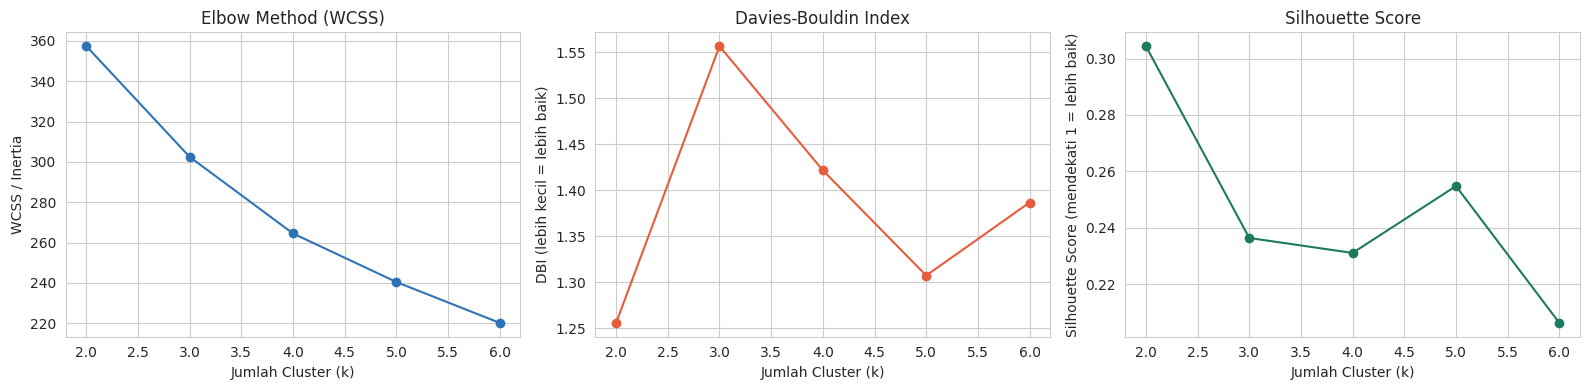

In [102]:
# Visualisasi Elbow Method, DBI, dan Silhouette Score
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(df_eval['k'], df_eval['WCSS'], marker='o', color='#2E74B5')
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('WCSS / Inertia')

axes[1].plot(df_eval['k'], df_eval['DBI'], marker='o', color='#E55D3A')
axes[1].set_title('Davies-Bouldin Index')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('DBI (lebih kecil = lebih baik)')

axes[2].plot(df_eval['k'], df_eval['Silhouette'], marker='o', color='#1E7A5F')
axes[2].set_title('Silhouette Score')
axes[2].set_xlabel('Jumlah Cluster (k)')
axes[2].set_ylabel('Silhouette Score (mendekati 1 = lebih baik)')

plt.tight_layout()
plt.show()

**Kesimpulan pemilihan k:** Berdasarkan grafik di atas, **k = 3** dipilih sebagai jumlah cluster optimal karena:
1. Elbow Method menunjukkan penurunan WCSS paling signifikan terjadi dari k=2 ke k=3, kemudian melandai.
2. Silhouette Score pada k=3 merupakan nilai tertinggi di antara seluruh k yang diuji.
3. Secara substantif, k=3 menghasilkan pembagian cluster yang paling bermakna dan dapat diinterpretasikan.

## 6. Data Mining — K-Means Clustering (k=3)

In [103]:
K_OPTIMAL = 3

kmeans_final = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=10, random_state=42, max_iter=200)
df['cluster'] = kmeans_final.fit_predict(X_scaled)
df_features['cluster'] = df['cluster']

# Evaluasi akhir
sil_final = silhouette_score(X_scaled, df['cluster'])
dbi_final = davies_bouldin_score(X_scaled, df['cluster'])

print(f'WCSS (Inertia)    : {kmeans_final.inertia_:.4f}')
print(f'Silhouette Score  : {sil_final:.4f}')
print(f'Davies-Bouldin Idx: {dbi_final:.4f}')
print()
print('Distribusi anggota cluster:')
print(df['cluster'].value_counts().sort_index())

WCSS (Inertia)    : 302.4991
Silhouette Score  : 0.2364
Davies-Bouldin Idx: 1.5565

Distribusi anggota cluster:
cluster
0    2067
1    1813
2    1120
Name: count, dtype: int64


## 7. Interpretasi — Centroid pada Skala Asli

In [104]:
# Kembalikan centroid ke skala asli (0-100)
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

df_centroids = pd.DataFrame(centroids_original, columns=FEATURES)
df_centroids.index = [f'Cluster {i+1}' for i in range(K_OPTIMAL)]
df_centroids['Jumlah Guru'] = df['cluster'].value_counts().sort_index().values
df_centroids['Persentase'] = (df_centroids['Jumlah Guru'] / len(df) * 100).round(1)

df_centroids.round(2)

,ACH,AIN,CAF,COP,SCO,Jumlah Guru,Persentase
Cluster 1,71.02,61.22,65.10,68.86,76.96,2067,41.3
Cluster 2,47.81,57.40,55.65,66.17,69.97,1813,36.3
Cluster 3,77.92,73.50,80.76,78.80,86.63,1120,22.4


In [105]:
# Rata-rata aktual per cluster
cluster_means = df_features.groupby('cluster')[FEATURES].mean().round(2)
cluster_means.index = [f'Cluster {i+1}' for i in cluster_means.index]
cluster_means

,ACH,AIN,CAF,COP,SCO
Cluster 1,71.00,61.22,65.08,68.86,76.91
Cluster 2,47.78,57.41,55.65,66.17,69.98
Cluster 3,77.92,73.47,80.75,78.79,86.66


## 8. Visualisasi Hasil Clustering

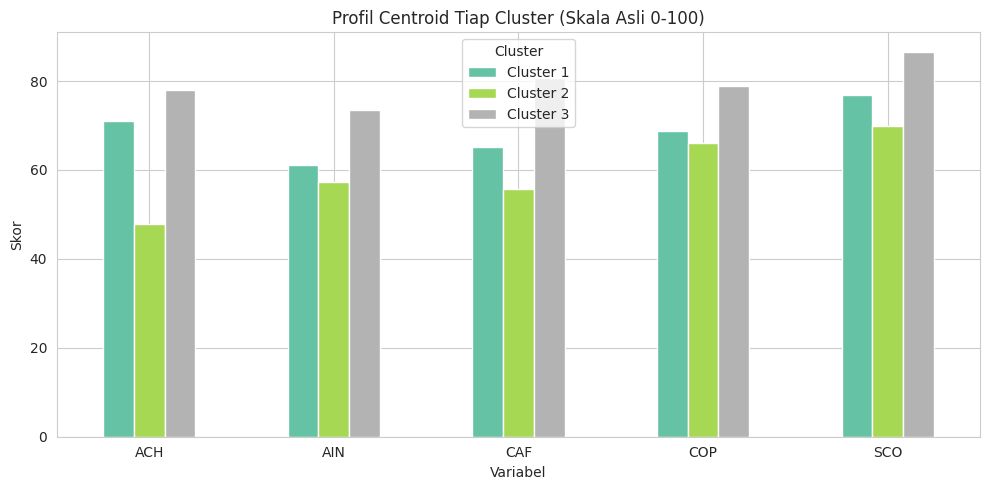

In [106]:
# bar chart profil centroid per cluster
df_plot = df_centroids[FEATURES].T
df_plot.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Profil Centroid Tiap Cluster (Skala Asli 0-100)')
plt.ylabel('Skor')
plt.xlabel('Variabel')
plt.xticks(rotation=0)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

/tmp/ipykernel_769/3650725889.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=col, data=df_features, ax=axes[i], palette='Set2')
/tmp/ipykernel_769/3650725889.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=col, data=df_features, ax=axes[i], palette='Set2')
/tmp/ipykernel_769/3650725889.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=col, data=df_features, ax=axes[i], palette='Set2')
/tmp/ipykernel_769/3650725889.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is depre

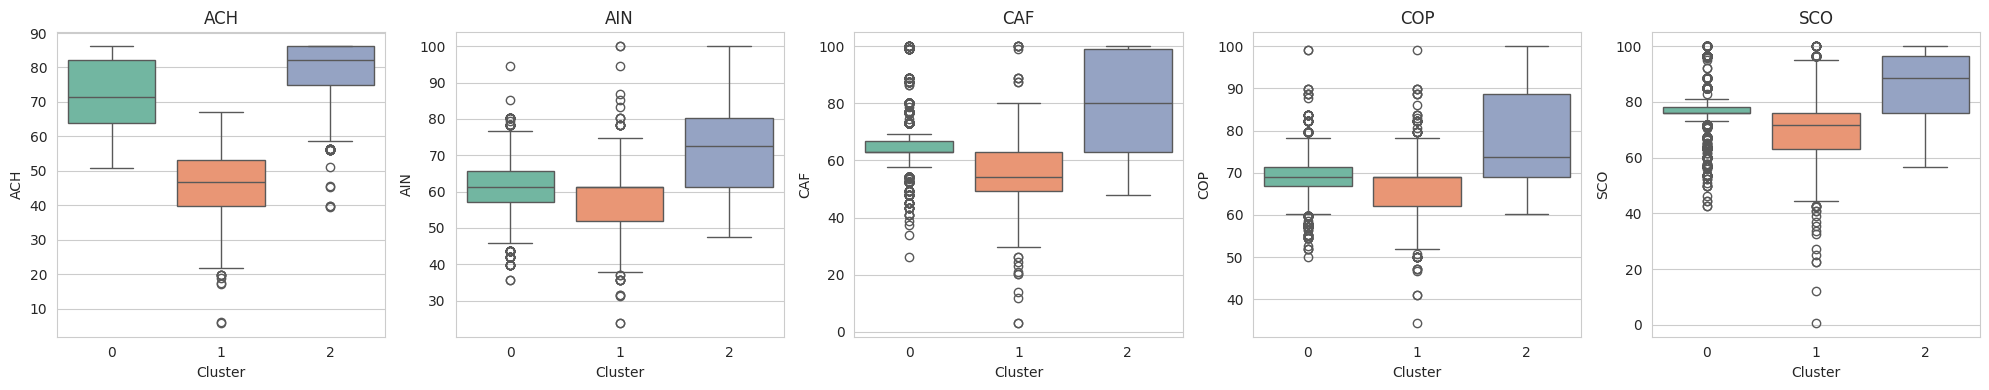

In [107]:
# Boxplot distribusi tiap variabel per cluster
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(FEATURES):
    sns.boxplot(x='cluster', y=col, data=df_features, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('Cluster')
plt.tight_layout()
plt.show()

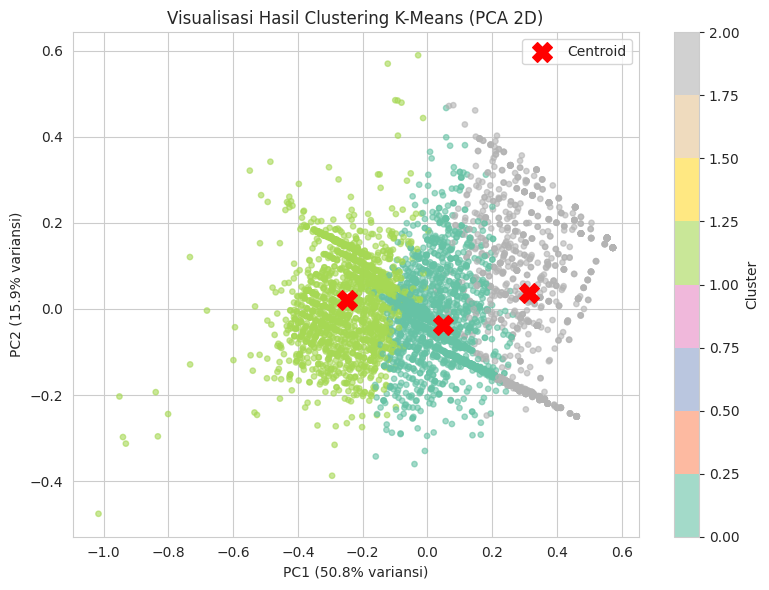

In [108]:
# Visualisasi 2D menggunakan PCA (Principal Component Analysis)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='Set2', alpha=0.6, s=15)

# Plot centroid pada ruang PCA
centroids_pca = pca.transform(centroids_scaled)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Centroid')

plt.title('Visualisasi Hasil Clustering K-Means (PCA 2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variansi)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variansi)')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## 9. Penamaan Label Cluster (Interpretasi Kualitatif)

Berdasarkan profil centroid:
- **Cluster 1** — ACH & COP tinggi, AIN & CAF sedang → **"Guru Kompeten & Adaptif Tinggi"**
- **Cluster 2** — Semua nilai rendah-sedang → **"Guru Kompetensi Berkembang"**
- **Cluster 3** — CAF & SCO sangat tinggi → **"Guru Reflektif & Sejahtera Tinggi"**

> **Catatan:** Urutan/penomoran cluster (0, 1, 2) hasil dari `KMeans` bersifat acak tergantung random_state. Sesuaikan pemetaan label berikut dengan urutan centroid hasil run Anda (lihat tabel `df_centroids` pada bagian 7).

In [109]:
# Sesuaikan mapping berikut berdasarkan urutan cluster pada output
# Cek dulu df_centroids untuk menentukan cluster mana yang sesuai label berikut
print(df_centroids.round(2))

label_mapping = {
    0: 'Guru Kompeten & Adaptif Tinggi',
    1: 'Guru Kompetensi Berkembang',
    2: 'Guru Reflektif & Sejahtera Tinggi',
}

df['label_cluster'] = df['cluster'].map(label_mapping)
df[['cluster', 'label_cluster'] + FEATURES].head(10)

             ACH    AIN    CAF    COP    SCO  Jumlah Guru  Persentase
Cluster 1  71.02  61.22  65.10  68.86  76.96         2067        41.3
Cluster 2  47.81  57.40  55.65  66.17  69.97         1813        36.3
Cluster 3  77.92  73.50  80.76  78.80  86.63         1120        22.4


,cluster,label_cluster,ACH,AIN,CAF,COP,SCO
0,2,Guru Reflektif & Sejahtera Tinggi,82.0492,100.0000,NaN,100.0000,NaN
1,0,Guru Kompeten & Adaptif Tinggi,56.3145,78.3618,62.9948,NaN,96.5459
2,1,Guru Kompetensi Berkembang,45.3534,NaN,66.6665,57.8541,63.7742
3,0,Guru Kompeten & Adaptif Tinggi,82.0492,70.0155,NaN,64.4635,NaN
4,1,Guru Kompetensi Berkembang,53.0580,74.8069,NaN,62.1459,NaN
5,2,Guru Reflektif & Sejahtera Tinggi,82.0492,70.0155,NaN,79.6567,NaN
6,0,Guru Kompeten & Adaptif Tinggi,64.0190,57.1098,NaN,69.0987,NaN
7,1,Guru Kompetensi Berkembang,53.0580,53.1685,NaN,64.4635,NaN
8,0,Guru Kompeten & Adaptif Tinggi,58.5385,74.8069,NaN,59.6567,NaN
9,1,Guru Kompetensi Berkembang,40.9055,48.2998,42.0446,NaN,24.9368


## 10. Analisis Tambahan — Distribusi Cluster Berdasarkan Karakteristik Sekolah



In [110]:
for col in ['jenis_sek', 'sts_sek', 'jenis_wilayah']:
    if col in df.columns:
        print(f'\n=== Distribusi Cluster vs {col} ===')
        ct = pd.crosstab(df['label_cluster'], df[col], normalize='index') * 100
        print(ct.round(1))


=== Distribusi Cluster vs jenis_sek ===
jenis_sek                           MTs  PPS Wustha  Paket B  Paket C   SMP
label_cluster                                                              
Guru Kompeten & Adaptif Tinggi     18.9         0.1      0.3      0.0  80.7
Guru Kompetensi Berkembang         27.9         0.3      0.8      0.0  71.0
Guru Reflektif & Sejahtera Tinggi  10.4         0.1      0.1      0.0  89.4

=== Distribusi Cluster vs sts_sek ===
sts_sek                               N     S
label_cluster                                
Guru Kompeten & Adaptif Tinggi     70.4  29.6
Guru Kompetensi Berkembang         60.6  39.4
Guru Reflektif & Sejahtera Tinggi  77.8  22.2

=== Distribusi Cluster vs jenis_wilayah ===
jenis_wilayah                      KABUPATEN  KOTA
label_cluster                                     
Guru Kompeten & Adaptif Tinggi          73.9  26.1
Guru Kompetensi Berkembang              76.1  23.9
Guru Reflektif & Sejahtera Tinggi       71.9  28.1


## 11. Ekspor Hasil

In [113]:
# Simpan hasil ke file CSV
output_cols = ['cluster', 'label_cluster'] + FEATURES
if 'kd_guru_an' in df.columns:
    output_cols = ['kd_guru_an'] + output_cols

df_output = df[output_cols]
df_output.to_csv('hasil_clustering_guru_AN2025.csv', index=False)

# Simpan tabel centroid & evaluasi
df_centroids.to_csv('centroid_cluster.csv')
df_eval.to_csv('evaluasi_k.csv', index=False)

print('File berhasil disimpan:')
print('- hasil_clustering_guru_AN2025.csv')
print('- centroid_cluster.csv')
print('- evaluasi_k.csv')

# Download di Colab
from google.colab import files as colab_files
colab_files.download('hasil_clustering_guru_AN2025.csv')
colab_files.download('centroid_cluster.csv')
colab_files.download('evaluasi_k.csv')

File berhasil disimpan:
- hasil_clustering_guru_AN2025.csv
- centroid_cluster.csv
- evaluasi_k.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### Ringkasan Hasil (untuk artikel/proposal)

Jalankan sel di bawah untuk menampilkan ringkasan akhir yang dapat disalin ke laporan.

In [112]:
print('='*60)
print('RINGKASAN HASIL K-MEANS CLUSTERING')
print('='*60)
print(f'Jumlah sampel        : {len(df)}')
print(f'Jumlah cluster (k)   : {K_OPTIMAL}')
print(f'WCSS (Inertia)       : {kmeans_final.inertia_:.4f}')
print(f'Silhouette Score     : {sil_final:.4f}')
print(f'Davies-Bouldin Index : {dbi_final:.4f}')
print()
print('Tabel Evaluasi k=2..6:')
print(df_eval.to_string(index=False))
print()
print('Tabel Centroid & Ukuran Cluster:')
print(df_centroids.round(2).to_string())

RINGKASAN HASIL K-MEANS CLUSTERING
Jumlah sampel        : 5000
Jumlah cluster (k)   : 3
WCSS (Inertia)       : 302.4991
Silhouette Score     : 0.2364
Davies-Bouldin Index : 1.5565

Tabel Evaluasi k=2..6:
 k     WCSS    DBI  Silhouette
 2 357.4219 1.2556      0.3044
 3 302.4991 1.5565      0.2364
 4 264.5256 1.4215      0.2311
 5 240.4456 1.3071      0.2548
 6 220.1815 1.3865      0.2063

Tabel Centroid & Ukuran Cluster:
             ACH    AIN    CAF    COP    SCO  Jumlah Guru  Persentase
Cluster 1  71.02  61.22  65.10  68.86  76.96         2067        41.3
Cluster 2  47.81  57.40  55.65  66.17  69.97         1813        36.3
Cluster 3  77.92  73.50  80.76  78.80  86.63         1120        22.4
